## PolyWorld: Part 1 (Prediction) and Part 2 (Fine-Tuning)

This notebook is structured in two main parts:
1.  **Part 1: Prediction with Pre-trained Model**: Apply the original PolyWorld model to the **test dataset** to establish a baseline performance.
2.  **Part 2: Fine-Tuning the Model**: Train the model on your custom **training dataset**.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from PIL import Image, ImageDraw
from pathlib import Path
import sys
import json
from tqdm.notebook import tqdm

# To parse the WKT strings in your labels
from shapely import wkt as shapely_wkt

# Add the cloned repository to Python's path
sys.path.insert(0, '/media/gisense/xihan/250812_tamu_cybertraining_team4/PolyWorld')

# Import the three main components of the PolyWorld pipeline
from models.backbone import R2U_Net, NonMaxSuppression, DetectionBranch
from models.matching import OptimalMatching

print("✅ Imports and paths set up.")

✅ Imports and paths set up.


## Part 1: Prediction with Pre-trained Model

Here, we run the original, pre-trained model on the **test images** to get a baseline result. The predictions will be saved to a JSON file for later evaluation.


In [ ]:
class SimpleImageDataset(Dataset):
    def __init__(self, images_dir, image_size=(1024, 1024)):  # Add image_size parameter
        self.image_paths = sorted([p for p in Path(images_dir).glob("*_pre_disaster.png")])
        self.image_size = image_size
        print(f"Found {len(self.image_paths)} images for prediction.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img_original = Image.open(img_path).convert('RGB')
        self.orig_size = img_original.size  # Store for later coordinate conversion
        
        # Resize to model's expected size
        img = img_original.resize(self.image_size, Image.Resampling.BILINEAR)
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        
        return {
            'image': img_tensor, 
            'image_path': str(img_path),
            'original_size': self.orig_size  # Pass original size for coordinate rescaling
        }

# Helper function to calculate a bounding box from polygon points
def bounding_box_from_points(points):
    points = np.array(points).flatten()
    X = points[0::2]
    Y = points[1::2]
    bbox = [X.min(), Y.min(), X.max() - X.min(), Y.max() - Y.min()]
    return [int(b) for b in bbox]

# Helper function to format the output JSON
def format_prediction(image_path, poly):
    return {
        "image_id": Path(image_path).stem,
        "category_id": 1, # Building
        "score": 1.0, # Model doesn't provide per-polygon score
        "segmentation": poly,
        "bbox": bounding_box_from_points(poly)
    }

def run_prediction(model_weights_dir, output_dir):
    """Runs the full prediction pipeline and saves individual JSON files per image."""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # --- Load model components ---
    backbone = R2U_Net().to(device)
    head = DetectionBranch().to(device)
    matching = OptimalMatching().to(device)
    suppression = NonMaxSuppression().to(device)

    # --- Load weights ---
    print(f"Loading weights from: {model_weights_dir}")
    backbone.load_state_dict(torch.load(model_weights_dir / "polyworld_backbone", map_location=device))
    head.load_state_dict(torch.load(model_weights_dir / "polyworld_seg_head", map_location=device))
    matching.load_state_dict(torch.load(model_weights_dir / "polyworld_matching", map_location=device))

    backbone.train(); head.train(); matching.train()
    print("✅ Models loaded.")

    # --- Run Prediction on TEST data ---
    test_images_dir = "/media/data/building_instance_tamu/test/images"
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    dataset = SimpleImageDataset(images_dir=test_images_dir, image_size=(1024, 1024))
    dataloader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=4)
    
    total_predictions = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting"):
            images = batch['image'].to(device)
            image_paths = batch['image_path']
            original_sizes = batch['original_size']
            
            features = backbone(images)
            occupancy_grid = head(features)
            _, graph_pressed = suppression(occupancy_grid)
            polygons_batch = matching.predict(images, features, graph_pressed)

            # Save individual JSON file for each image
            for i, polys in enumerate(polygons_batch):
                # Get original image size
                orig_w, orig_h = original_sizes[0][i].item(), original_sizes[1][i].item()
                
                image_predictions = []
                for p in polys:
                    # PolyWorld outputs in "COCO format" which is already in pixel coordinates (0-1024 range)
                    # BUT it's scaled by 300/320 and we need to scale to original image size
                    
                    # The polygon p is a flat list: [x1, y1, x2, y2, ...]
                    # PolyWorld already applied: coords * 300/320, so we need to reverse and scale properly
                    
                    scaled_poly = []
                    for j in range(0, len(p), 2):
                        # Get coordinates in PolyWorld's output space (scaled by 300/320)
                        x_pw = p[j]
                        y_pw = p[j+1]
                        
                        # Reverse PolyWorld's 300/320 scaling to get back to 0-1024 space
                        x_1024 = x_pw * 320.0 / 300.0
                        y_1024 = y_pw * 320.0 / 300.0
                        
                        # Now scale from 1024x1024 to original image size
                        x_orig = x_1024 * orig_w / 1024.0
                        y_orig = y_1024 * orig_h / 1024.0
                        
                        scaled_poly.extend([x_orig, y_orig])
                    
                    image_predictions.append(format_prediction(image_paths[i], [scaled_poly]))
                
                # Save to individual JSON file
                image_name = Path(image_paths[i]).stem
                output_file = output_dir / f"{image_name}.json"
                
                with open(output_file, 'w') as f:
                    json.dump(image_predictions, f, indent=2)
                
                total_predictions += len(image_predictions)

    print(f"\n✅ Prediction complete. Saved {len(dataset)} JSON files to {output_dir}")
    print(f"Total predictions: {total_predictions}")

In [3]:
# --- Run with PRE-TRAINED weights ---
pretrained_weights_dir = Path("/media/gisense/xihan/250812_tamu_cybertraining_team4/PolyWorld/trained_weights")
run_prediction(
    model_weights_dir=pretrained_weights_dir, 
    output_dir="/media/data/building_instance_tamu/PolyWorld/test_pretrained",
)

Using device: cuda
Loading weights from: /media/gisense/xihan/250812_tamu_cybertraining_team4/PolyWorld/trained_weights
✅ Models loaded.
Found 933 images for prediction.


Predicting:   0%|          | 0/234 [00:00<?, ?it/s]


✅ Prediction complete. Saved 933 JSON files to /media/data/building_instance_tamu/PolyWorld/test_pretrained
Total predictions: 6036


Found 934 PolyWorld prediction files

Randomly selected: hurricane-florence_00000176_pre_disaster.json

✅ Found all files for: hurricane-florence_00000176_pre_disaster
  - Image: hurricane-florence_00000176_pre_disaster.png
  - Ground Truth: hurricane-florence_00000176_pre_disaster.json
  - Prediction: hurricane-florence_00000176_pre_disaster.json



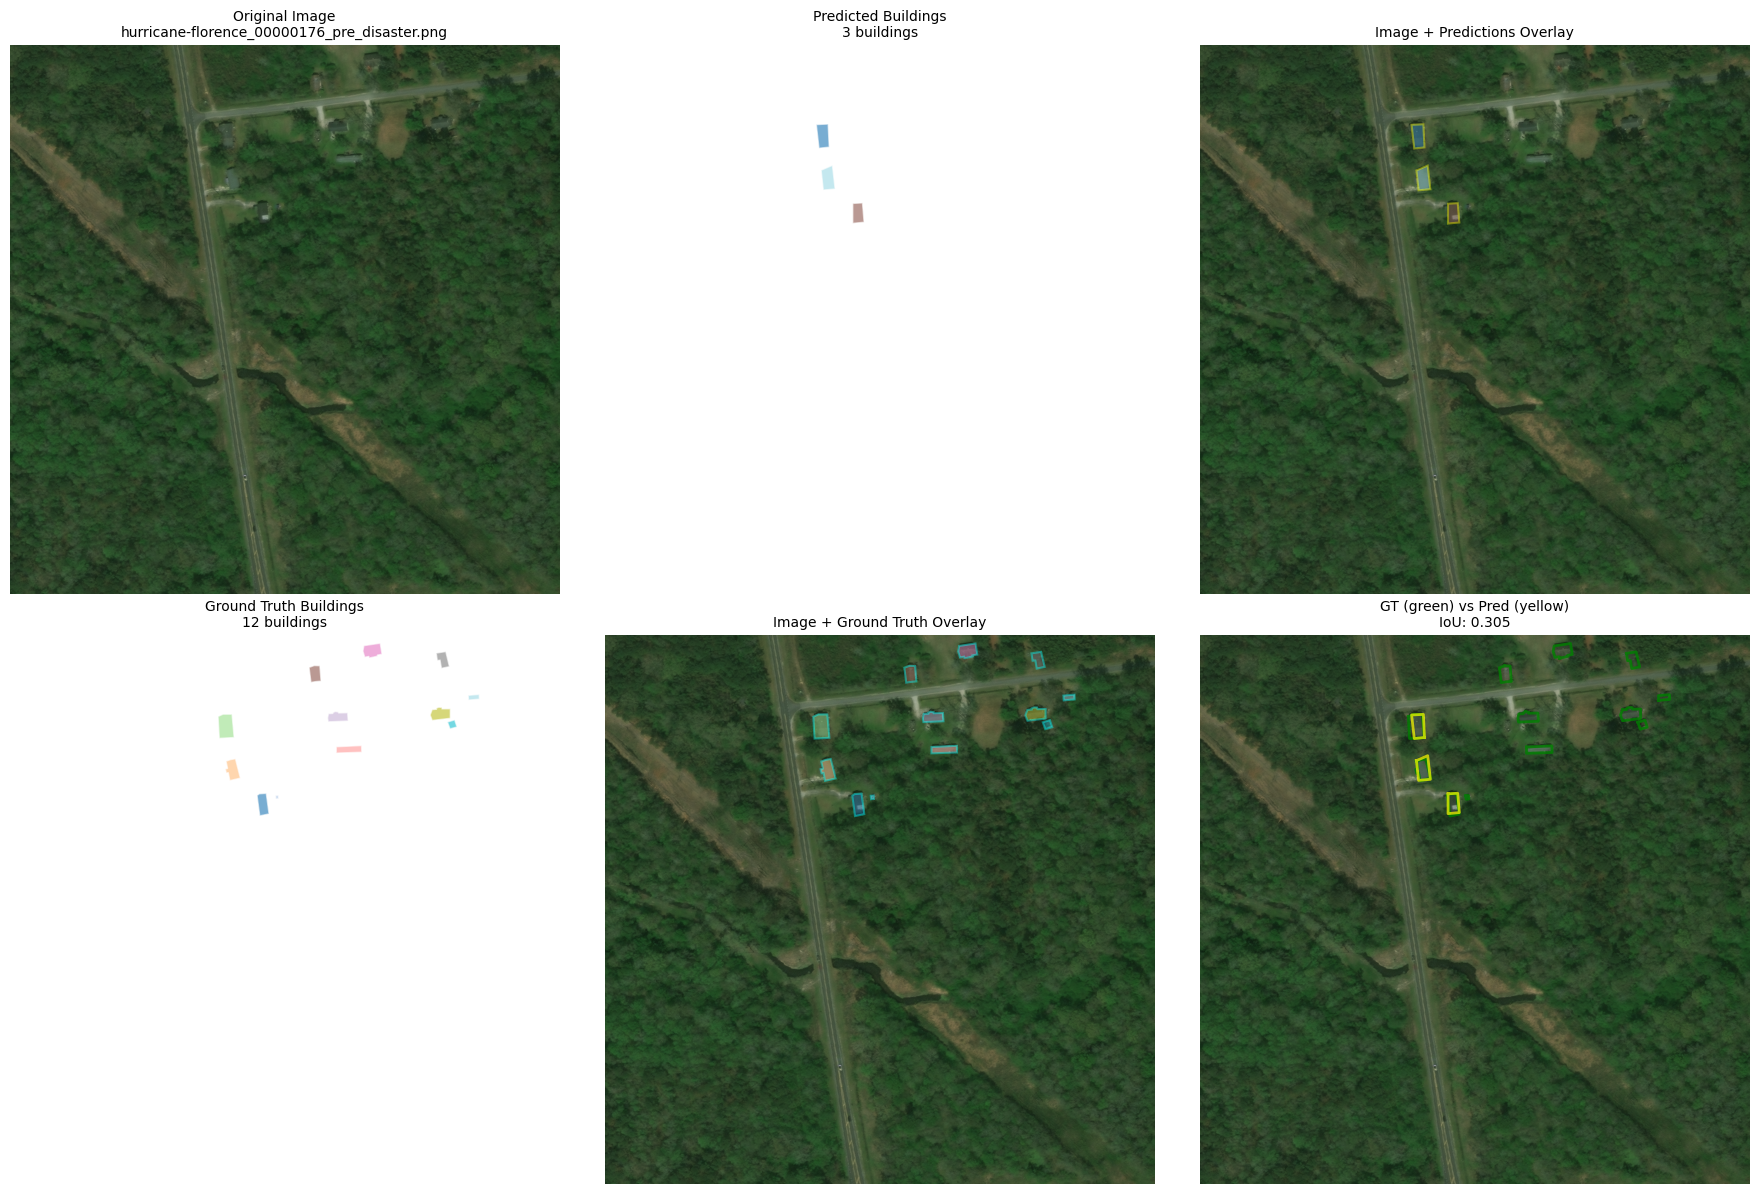


Image: hurricane-florence_00000176_pre_disaster.png
Ground Truth Buildings: 12
Predicted Buildings: 3
Difference: -9
Image size: 1024 x 1024

📊 IoU Metrics:
  Overall IoU (pixel-based): 0.3054 (30.54%)
  Mean Per-Polygon IoU: 0.1867 (18.67%)
  Min IoU: 0.0000
  Max IoU: 0.7795
  Polygons with IoU > 0.5: 3/12



In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from shapely import wkt as shapely_wkt
from shapely.geometry import Polygon
import random

def polygon_from_segmentation(segmentation):
    """Convert segmentation list to shapely polygon"""
    if not segmentation or len(segmentation[0]) < 6:
        return None
    coords = segmentation[0]
    points = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
    return Polygon(points)

def calculate_polygon_iou(gt_features, pred_list, img_width, img_height):
    """
    Calculate IoU between ground truth and predicted polygons
    
    Args:
        gt_features: Ground truth polygon features (from label JSON with 'wkt' format)
        pred_list: List of prediction dictionaries (from PolyWorld output with 'segmentation' format)
        img_width: Image width
        img_height: Image height
    
    Returns:
        overall_iou: Overall pixel-based IoU
        mean_per_polygon_iou: Mean per-polygon IoU
        per_polygon_ious: List of IoU scores for matched polygons
    """
    # Create binary masks for ground truth and predictions
    from PIL import ImageDraw
    gt_img = Image.new('L', (img_width, img_height), 0)
    draw_gt = ImageDraw.Draw(gt_img)
    
    for feature in gt_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            coords_int = [(int(x), int(y)) for x, y in coords]
            draw_gt.polygon(coords_int, fill=1)
    
    gt_mask = np.array(gt_img)
    
    # Draw predicted polygons
    pred_img = Image.new('L', (img_width, img_height), 0)
    draw_pred = ImageDraw.Draw(pred_img)
    
    for pred in pred_list:
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            coords_int = [(int(x), int(y)) for x, y in coords]
            draw_pred.polygon(coords_int, fill=1)
    
    pred_mask = np.array(pred_img)
    
    # Calculate overall IoU
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    overall_iou = intersection / union if union > 0 else 0.0
    
    # Calculate per-polygon IoU using Shapely
    gt_polygons = []
    pred_polygons = []
    
    for feature in gt_features:
        try:
            poly = shapely_wkt.loads(feature['wkt'])
            if poly.is_valid:
                gt_polygons.append(poly)
        except:
            pass
    
    for pred in pred_list:
        try:
            poly = polygon_from_segmentation(pred['segmentation'])
            if poly and poly.is_valid:
                pred_polygons.append(poly)
        except:
            pass
    
    # Calculate best match IoU for each ground truth polygon
    per_polygon_ious = []
    for gt_poly in gt_polygons:
        best_iou = 0.0
        for pred_poly in pred_polygons:
            try:
                intersection_area = gt_poly.intersection(pred_poly).area
                union_area = gt_poly.union(pred_poly).area
                if union_area > 0:
                    current_iou = intersection_area / union_area
                    best_iou = max(best_iou, current_iou)
            except:
                pass
        per_polygon_ious.append(best_iou)
    
    mean_per_polygon_iou = np.mean(per_polygon_ious) if per_polygon_ious else 0.0
    
    return overall_iou, mean_per_polygon_iou, per_polygon_ious


def visualize_predictions_with_ground_truth(image_path, pred_json_path, gt_json_path):
    """
    Visualize PolyWorld predictions vs ground truth with 6 panels
    
    Args:
        image_path: Path to the pre-disaster image
        pred_json_path: Path to the PolyWorld prediction JSON file
        gt_json_path: Path to the ground truth JSON file
    """
    # Load image
    img = Image.open(image_path)
    img_array = np.array(img)
    
    # Load prediction JSON (PolyWorld format - list of predictions)
    with open(pred_json_path, 'r') as f:
        predictions = json.load(f)
    
    # Load ground truth JSON
    with open(gt_json_path, 'r') as f:
        ground_truth = json.load(f)
    gt_xy_features = ground_truth['features']['xy']
    
    # Calculate IoU
    overall_iou, mean_polygon_iou, per_polygon_ious = calculate_polygon_iou(
        gt_xy_features, predictions, img_array.shape[1], img_array.shape[0]
    )
    
    # Create figure with 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # ROW 1: PREDICTIONS
    # 1. Original image
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title(f"Original Image\n{Path(image_path).name}", fontsize=10)
    axes[0, 0].axis('off')
    
    # 2. Predicted polygons only
    axes[0, 1].set_xlim(0, img_array.shape[1])
    axes[0, 1].set_ylim(img_array.shape[0], 0)
    axes[0, 1].set_aspect('equal')
    axes[0, 1].set_facecolor('black')
    axes[0, 1].set_title(f"Predicted Buildings\n{len(predictions)} buildings", fontsize=10)
    axes[0, 1].axis('off')
    
    # Draw predicted polygons
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(predictions), 1)))
    for idx, pred in enumerate(predictions):
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[0, 1].fill(x_coords, y_coords, color=color, alpha=0.6, edgecolor='white', linewidth=1)
    
    # 3. Overlay - Image + Predictions
    axes[0, 2].imshow(img_array)
    axes[0, 2].set_title("Image + Predictions Overlay", fontsize=10)
    axes[0, 2].axis('off')
    
    for idx, pred in enumerate(predictions):
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[0, 2].fill(x_coords, y_coords, color=color, alpha=0.4, edgecolor='yellow', linewidth=1.5)
    
    # ROW 2: GROUND TRUTH & COMPARISON
    # 4. Ground truth polygons only
    axes[1, 0].set_xlim(0, img_array.shape[1])
    axes[1, 0].set_ylim(img_array.shape[0], 0)
    axes[1, 0].set_aspect('equal')
    axes[1, 0].set_facecolor('black')
    axes[1, 0].set_title(f"Ground Truth Buildings\n{len(gt_xy_features)} buildings", fontsize=10)
    axes[1, 0].axis('off')
    
    # Draw ground truth polygons
    gt_colors = plt.cm.tab20(np.linspace(0, 1, max(len(gt_xy_features), 1)))
    for idx, feature in enumerate(gt_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = gt_colors[idx % len(gt_colors)]
            axes[1, 0].fill(x_coords, y_coords, color=color, alpha=0.6, edgecolor='white', linewidth=1)
    
    # 5. Image + Ground Truth Overlay
    axes[1, 1].imshow(img_array)
    axes[1, 1].set_title("Image + Ground Truth Overlay", fontsize=10)
    axes[1, 1].axis('off')
    
    for idx, feature in enumerate(gt_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = gt_colors[idx % len(gt_colors)]
            axes[1, 1].fill(x_coords, y_coords, color=color, alpha=0.4, edgecolor='cyan', linewidth=1.5)
    
    # 6. Ground truth (green) vs Predictions (yellow)
    axes[1, 2].imshow(img_array)
    axes[1, 2].set_title(f"GT (green) vs Pred (yellow)\nIoU: {overall_iou:.3f}", fontsize=10)
    axes[1, 2].axis('off')
    
    # Draw ground truth in green
    for feature in gt_xy_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            axes[1, 2].plot(x_coords, y_coords, color='green', linewidth=2, alpha=0.8)
    
    # Draw predictions in yellow
    for pred in predictions:
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            axes[1, 2].plot(x_coords, y_coords, color='yellow', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics with IoU
    print(f"\n{'='*70}")
    print(f"Image: {Path(image_path).name}")
    print(f"Ground Truth Buildings: {len(gt_xy_features)}")
    print(f"Predicted Buildings: {len(predictions)}")
    print(f"Difference: {len(predictions) - len(gt_xy_features):+d}")
    print(f"Image size: {img_array.shape[1]} x {img_array.shape[0]}")
    print(f"\n📊 IoU Metrics:")
    print(f"  Overall IoU (pixel-based): {overall_iou:.4f} ({overall_iou*100:.2f}%)")
    print(f"  Mean Per-Polygon IoU: {mean_polygon_iou:.4f} ({mean_polygon_iou*100:.2f}%)")
    if per_polygon_ious:
        print(f"  Min IoU: {min(per_polygon_ious):.4f}")
        print(f"  Max IoU: {max(per_polygon_ious):.4f}")
        print(f"  Polygons with IoU > 0.5: {sum(1 for x in per_polygon_ious if x > 0.5)}/{len(per_polygon_ious)}")
    print(f"{'='*70}\n")


# Paths for PolyWorld predictions
pred_labels_dir = Path("/media/data/building_instance_tamu/PolyWorld/test_pretrained")
gt_labels_dir = Path("/media/data/building_instance_tamu/test/labels")
images_dir = Path("/media/data/building_instance_tamu/test/images")

# Get all prediction JSON files
pred_json_files = list(pred_labels_dir.glob("*.json"))
print(f"Found {len(pred_json_files)} PolyWorld prediction files\n")

if len(pred_json_files) > 0:
    # Randomly select one file to visualize
    random_index = random.randint(0, len(pred_json_files)-1)
    pred_json_path = pred_json_files[random_index]
    
    print(f"Randomly selected: {pred_json_path.name}\n")
    
    # Find corresponding files
    base_name = pred_json_path.stem
    img_path = images_dir / f"{base_name}.png"
    gt_json_path = gt_labels_dir / f"{base_name}.json"
    
    # Check if all files exist
    if all([img_path.exists(), gt_json_path.exists()]):
        print(f"✅ Found all files for: {base_name}")
        print(f"  - Image: {img_path.name}")
        print(f"  - Ground Truth: {gt_json_path.name}")
        print(f"  - Prediction: {pred_json_path.name}\n")
        
        visualize_predictions_with_ground_truth(img_path, pred_json_path, gt_json_path)
    else:
        print("❌ Missing files:")
        if not img_path.exists():
            print(f"  - Image: {img_path}")
        if not gt_json_path.exists():
            print(f"  - Ground Truth: {gt_json_path}")
else:
    print("❌ No prediction files found. Please run Part 1 first to generate predictions.")

## Part 2: Fine_Tunning with Pre-trained Model
We will fine-tune it one the train data set and test on test data set again


In [2]:
# class BuildingTrainDataset(Dataset):
#     def __init__(self, images_dir, labels_dir, image_size=(512, 512)):
#         self.image_paths = sorted([p for p in Path(images_dir).glob("*_pre_disaster.png")])
#         self.labels_dir = Path(labels_dir)
#         self.image_size = image_size
#         print(f"Found {len(self.image_paths)} images for training.")

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
        
#         # --- Load and process image ---
#         img = Image.open(img_path).convert('RGB').resize(self.image_size)
#         img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0

#         # --- Load label and create target grid ---
#         label_path = self.labels_dir / f"{img_path.stem}.json"
#         # The target grid must match the model's output size, which is the image_size
#         target_grid = torch.zeros(self.image_size, dtype=torch.float32)

#         if label_path.exists():
#             with open(label_path) as f:
#                 annotations = json.load(f)
            
#             # Get the original image size from metadata for scaling
#             meta = annotations.get("metadata", {})
#             orig_w = meta.get("width", self.image_size[0])
#             orig_h = meta.get("height", self.image_size[1])

#             # Get polygons from the 'xy' features
#             polygons = annotations["features"]["xy"]
#             for feat in polygons:
#                 try:
#                     poly = shapely_wkt.loads(feat['wkt'])
#                     for x, y in poly.exterior.coords:
#                         # Scale coordinates to the new grid size (which is now image_size)
#                         grid_x = int((x / orig_w) * self.image_size[1])
#                         grid_y = int((y / orig_h) * self.image_size[0])
                        
#                         # Clamp values to be within grid bounds
#                         grid_x = max(0, min(grid_x, self.image_size[1] - 1))
#                         grid_y = max(0, min(grid_y, self.image_size[0] - 1))
                        
#                         # Mark this vertex in the target grid
#                         target_grid[grid_y, grid_x] = 1.0
#                 except Exception:
#                     continue # Skip invalid polygons

#         return {
#             'image': img_tensor,
#             'target_grid': target_grid.unsqueeze(0) # Add channel dimension
#         }

# print("✅ Custom Training Dataset defined.")

✅ Custom Training Dataset defined.


In [ ]:
class BuildingTrainDataset(Dataset):
    def __init__(self, images_dir, labels_dir, image_size=(1024, 1024)):  # Changed from (512, 512)
        self.image_paths = sorted([p for p in Path(images_dir).glob("*_pre_disaster.png")])
        self.labels_dir = Path(labels_dir)
        self.image_size = image_size
        print(f"Found {len(self.image_paths)} images for training.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        
        # --- Load image (get original size first) ---
        img_original = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img_original.size
        
        # Resize to model's expected size
        img = img_original.resize(self.image_size, Image.Resampling.BILINEAR)
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0

        # --- Load label and create target grid ---
        label_path = self.labels_dir / f"{img_path.stem}.json"
        target_grid = torch.zeros(self.image_size, dtype=torch.float32)

        if label_path.exists():
            with open(label_path) as f:
                annotations = json.load(f)
            
            # Use actual original dimensions, not from metadata
            polygons = annotations["features"]["xy"]
            
            # Calculate scaling factors
            scale_x = self.image_size[1] / orig_w
            scale_y = self.image_size[0] / orig_h
            
            for feat in polygons:
                try:
                    poly = shapely_wkt.loads(feat['wkt'])
                    for x, y in poly.exterior.coords:
                        # Scale coordinates from original image to resized grid
                        grid_x = int(x * scale_x)
                        grid_y = int(y * scale_y)
                        
                        # Clamp values to be within grid bounds
                        grid_x = max(0, min(grid_x, self.image_size[1] - 1))
                        grid_y = max(0, min(grid_y, self.image_size[0] - 1))
                        
                        # Mark this vertex in the target grid (with small radius for better learning)
                        for dy in range(-2, 3):
                            for dx in range(-2, 3):
                                ny, nx = grid_y + dy, grid_x + dx
                                if 0 <= ny < self.image_size[0] and 0 <= nx < self.image_size[1]:
                                    target_grid[ny, nx] = 1.0
                except Exception as e:
                    continue

        return {
            'image': img_tensor,
            'target_grid': target_grid.unsqueeze(0)
        }

In [8]:
# --- Setup paths and device ---
base_repo_dir = Path("/media/gisense/xihan/250812_tamu_cybertraining_team4/PolyWorld")
pretrained_weights_dir = base_repo_dir / "trained_weights"
finetuned_output_dir = Path("/media/data/building_instance_tamu/PolyWorld/finetuned_weights")
finetuned_output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Load model components for training ---
backbone = R2U_Net().to(device)
head = DetectionBranch().to(device)

# --- Load pretrained weights ---
backbone.load_state_dict(torch.load(pretrained_weights_dir / "polyworld_backbone", map_location=device))
head.load_state_dict(torch.load(pretrained_weights_dir / "polyworld_seg_head", map_location=device))

# --- Set models to training mode ---
backbone.train()
head.train()

# --- Define Optimizer and Loss Function ---
params = list(backbone.parameters()) + list(head.parameters())
optimizer = optim.Adam(params, lr=1e-5) # Small learning rate for fine-tuning
criterion = nn.BCEWithLogitsLoss() # Best for binary grid prediction

print("✅ Models loaded and training parameters are set.")

Using device: cuda
✅ Models loaded and training parameters are set.


In [9]:
## Check and Clear GPU Memory
import torch
import gc

# Check current GPU memory
print("GPU Memory Status:")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

# Clear cache
torch.cuda.empty_cache()
gc.collect()

print("\nAfter clearing cache:")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

GPU Memory Status:
Allocated: 0.15 GB
Reserved: 0.45 GB

After clearing cache:
Allocated: 0.15 GB
Reserved: 0.20 GB


In [ ]:
# --- Define data paths for TRAINING ---
train_images_dir = "/media/data/building_instance_tamu/train/images"
train_labels_dir = "/media/data/building_instance_tamu/train/labels"

# --- Set up the dataloader ---
train_dataset = BuildingTrainDataset(images_dir=train_images_dir, labels_dir=train_labels_dir)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=4)

# --- Training Loop ---
num_epochs = 20 # Adjust as needed
print(f"\nStarting fine-tuning for {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for batch in progress_bar:
        images = batch['image'].to(device)
        target_grids = batch['target_grid'].to(device)

        optimizer.zero_grad()
        features = backbone(images)
        predicted_grids = head(features)
        loss = criterion(predicted_grids, target_grids)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} finished. Average Loss: {avg_epoch_loss:.6f}")

print("\n✅ Fine-tuning complete.")

# --- Save the fine-tuned weights ---
torch.save(backbone.state_dict(), finetuned_output_dir / "polyworld_backbone")
torch.save(head.state_dict(), finetuned_output_dir / "polyworld_seg_head")
# The matching network was not trained, so copy its weights
import shutil
shutil.copy(pretrained_weights_dir / "polyworld_matching", finetuned_output_dir / "polyworld_matching")

print(f"Fine-tuned weights saved to: {finetuned_output_dir}")

Found 2799 images for training.

Starting fine-tuning for 20 epochs...


Epoch 1/20:   0%|          | 0/1400 [00:00<?, ?it/s]

Epoch 1 finished. Average Loss: 0.035370


Epoch 2/20:   0%|          | 0/1400 [00:00<?, ?it/s]

Epoch 2 finished. Average Loss: 0.028530


...

Epoch 18 finished. Average Loss: 0.022559


Epoch 19/20:   0%|          | 0/1400 [00:00<?, ?it/s]

Epoch 19 finished. Average Loss: 0.022248


Epoch 20/20:   0%|          | 0/1400 [00:00<?, ?it/s]

Epoch 20 finished. Average Loss: 0.022046

✅ Fine-tuning complete.
Fine-tuned weights saved to: /media/data/building_instance_tamu/PolyWorld/finetuned_weights


In [11]:
# --- Run with PRE-TRAINED weights ---
pretrained_weights_dir = Path("/media/data/building_instance_tamu/PolyWorld/finetuned_weights")
run_prediction(
    model_weights_dir=pretrained_weights_dir, 
    output_dir="/media/data/building_instance_tamu/PolyWorld/test_finetuned",
)

Using device: cuda
Loading weights from: /media/data/building_instance_tamu/PolyWorld/finetuned_weights
✅ Models loaded.
Found 933 images for prediction.


Predicting:   0%|          | 0/234 [00:00<?, ?it/s]


✅ Prediction complete. Saved 933 JSON files to /media/data/building_instance_tamu/PolyWorld/test_finetuned
Total predictions: 4799


In [30]:
# ENHANCED DIAGNOSTIC - Check each stage of the pipeline
def diagnose_model_pipeline():
    """Diagnose each stage of the PolyWorld pipeline"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load models
    backbone = R2U_Net().to(device)
    head = DetectionBranch().to(device)
    matching = OptimalMatching().to(device)
    suppression = NonMaxSuppression().to(device)
    
    pretrained_weights_dir = Path("/media/gisense/xihan/250812_tamu_cybertraining_team4/PolyWorld/trained_weights")
    backbone.load_state_dict(torch.load(pretrained_weights_dir / "polyworld_backbone", map_location=device))
    head.load_state_dict(torch.load(pretrained_weights_dir / "polyworld_seg_head", map_location=device))
    matching.load_state_dict(torch.load(pretrained_weights_dir / "polyworld_matching", map_location=device))
    
    backbone.eval(); head.eval(); matching.eval()
    
    # Load a test image
    test_img_path = list(Path("/media/data/building_instance_tamu/test/images").glob("*_pre_disaster.png"))[100]
    img_original = Image.open(test_img_path).convert('RGB')
    orig_w, orig_h = img_original.size
    
    print(f"Testing with: {test_img_path.name}")
    print(f"Original size: {orig_w} x {orig_h}")
    
    # Resize to 1024x1024
    img = img_original.resize((1024, 1024), Image.Resampling.BILINEAR)
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    
    print(f"\n📊 Input tensor shape: {img_tensor.shape}")
    print(f"   Value range: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")
    
    # Run inference step by step
    with torch.no_grad():
        # Step 1: Backbone
        features = backbone(img_tensor)
        print(f"\n1️⃣ Backbone output shape: {features.shape}")
        print(f"   Value range: [{features.min():.3f}, {features.max():.3f}]")
        
        # Step 2: Detection head
        occupancy_grid = head(features)
        print(f"\n2️⃣ Occupancy grid shape: {occupancy_grid.shape}")
        print(f"   Value range: [{occupancy_grid.min():.3f}, {occupancy_grid.max():.3f}]")
        print(f"   Max activation: {occupancy_grid.max():.3f}")
        
        # Apply sigmoid to see probabilities
        occupancy_probs = torch.sigmoid(occupancy_grid)
        print(f"   After sigmoid - Max prob: {occupancy_probs.max():.3f}")
        print(f"   Pixels > 0.5: {(occupancy_probs > 0.5).sum().item()}")
        print(f"   Pixels > 0.3: {(occupancy_probs > 0.3).sum().item()}")
        
        # Step 3: Non-max suppression
        _, graph_pressed = suppression(occupancy_grid)
        print(f"\n3️⃣ Graph pressed shape: {graph_pressed.shape}")
        print(f"   Non-zero vertices: {(graph_pressed.sum(dim=1) > 0).sum().item()}")
        
        # Step 4: Matching
        polygons_batch = matching.predict(img_tensor, features, graph_pressed)
        print(f"\n4️⃣ Matching output:")
        print(f"   Number of polygons: {len(polygons_batch[0])}")
        
        if len(polygons_batch[0]) > 0:
            print(f"   First polygon has {len(polygons_batch[0][0])//2} vertices")
        else:
            print("   ⚠️ No polygons generated!")
            print("\n   Possible reasons:")
            print("   - Occupancy grid activations too low")
            print("   - NMS threshold too strict")
            print("   - Matching network not finding valid polygons")

diagnose_model_pipeline()

Testing with: hurricane-harvey_00000063_pre_disaster.png
Original size: 1024 x 1024

📊 Input tensor shape: torch.Size([1, 3, 1024, 1024])
   Value range: [0.094, 1.000]

1️⃣ Backbone output shape: torch.Size([1, 64, 1024, 1024])
   Value range: [-1.410, 4.313]

2️⃣ Occupancy grid shape: torch.Size([1, 1, 1024, 1024])
   Value range: [-22.027, 0.656]
   Max activation: 0.656
   After sigmoid - Max prob: 0.658
   Pixels > 0.5: 6
   Pixels > 0.3: 10

3️⃣ Graph pressed shape: torch.Size([1, 256, 2])
   Non-zero vertices: 2

4️⃣ Matching output:
   Number of polygons: 0
   ⚠️ No polygons generated!

   Possible reasons:
   - Occupancy grid activations too low
   - NMS threshold too strict
   - Matching network not finding valid polygons


In [29]:
# DIAGNOSTIC: Test FINE-TUNED model
def diagnose_finetuned_model():
    """Diagnose the FINE-TUNED model pipeline"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load models
    backbone = R2U_Net().to(device)
    head = DetectionBranch().to(device)
    matching = OptimalMatching().to(device)
    suppression = NonMaxSuppression().to(device)
    
    # LOAD FINE-TUNED WEIGHTS
    finetuned_weights_dir = Path("/media/data/building_instance_tamu/PolyWorld/finetuned_weights")
    backbone.load_state_dict(torch.load(finetuned_weights_dir / "polyworld_backbone", map_location=device))
    head.load_state_dict(torch.load(finetuned_weights_dir / "polyworld_seg_head", map_location=device))
    matching.load_state_dict(torch.load(finetuned_weights_dir / "polyworld_matching", map_location=device))
    
    backbone.eval(); head.eval(); matching.eval()
    
    # Load a test image
    test_img_path = list(Path("/media/data/building_instance_tamu/test/images").glob("*_pre_disaster.png"))[100]
    img_original = Image.open(test_img_path).convert('RGB')
    orig_w, orig_h = img_original.size
    
    print(f"🔬 TESTING FINE-TUNED MODEL")
    print(f"Testing with: {test_img_path.name}")
    print(f"Original size: {orig_w} x {orig_h}")
    
    # Resize to 1024x1024
    img = img_original.resize((1024, 1024), Image.Resampling.BILINEAR)
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    
    print(f"\n📊 Input tensor shape: {img_tensor.shape}")
    
    # Run inference step by step
    with torch.no_grad():
        # Step 1: Backbone
        features = backbone(img_tensor)
        print(f"\n1️⃣ Backbone output shape: {features.shape}")
        print(f"   Value range: [{features.min():.3f}, {features.max():.3f}]")
        
        # Step 2: Detection head
        occupancy_grid = head(features)
        print(f"\n2️⃣ Occupancy grid shape: {occupancy_grid.shape}")
        print(f"   Value range: [{occupancy_grid.min():.3f}, {occupancy_grid.max():.3f}]")
        print(f"   Max activation: {occupancy_grid.max():.3f}")
        
        # Apply sigmoid to see probabilities
        occupancy_probs = torch.sigmoid(occupancy_grid)
        print(f"   After sigmoid - Max prob: {occupancy_probs.max():.3f}")
        print(f"   Pixels > 0.5: {(occupancy_probs > 0.5).sum().item()}")
        print(f"   Pixels > 0.3: {(occupancy_probs > 0.3).sum().item()}")
        print(f"   Pixels > 0.1: {(occupancy_probs > 0.1).sum().item()}")
        
        # Step 3: Non-max suppression
        _, graph_pressed = suppression(occupancy_grid)
        print(f"\n3️⃣ Graph pressed shape: {graph_pressed.shape}")
        print(f"   Non-zero vertices: {(graph_pressed.sum(dim=1) > 0).sum().item()}")
        
        # Print some actual vertex coordinates
        non_zero_mask = (graph_pressed.sum(dim=2) > 0).squeeze()
        if non_zero_mask.sum() > 0:
            vertices = graph_pressed.squeeze()[non_zero_mask]
            print(f"   First 5 vertices: {vertices[:5].cpu().numpy()}")
        
        # Step 4: Matching
        polygons_batch = matching.predict(img_tensor, features, graph_pressed)
        print(f"\n4️⃣ Matching output:")
        print(f"   Number of polygons: {len(polygons_batch[0])}")
        
        if len(polygons_batch[0]) > 0:
            print(f"   ✅ SUCCESS! Generated {len(polygons_batch[0])} polygons")
            print(f"   First polygon has {len(polygons_batch[0][0])//2} vertices")
            print(f"   First polygon coords (first 10): {polygons_batch[0][0][:10]}")
        else:
            print("   ⚠️ Still no polygons generated!")
            print("\n   Since loss is low, the issue is likely:")
            print("   - NMS threshold too strict (not enough vertices detected)")
            print("   - Matching network threshold too high")
            print("   - Coordinate space mismatch")

diagnose_finetuned_model()

🔬 TESTING FINE-TUNED MODEL
Testing with: hurricane-harvey_00000063_pre_disaster.png
Original size: 1024 x 1024

📊 Input tensor shape: torch.Size([1, 3, 1024, 1024])

1️⃣ Backbone output shape: torch.Size([1, 64, 1024, 1024])
   Value range: [-1.854, 5.567]

2️⃣ Occupancy grid shape: torch.Size([1, 1, 1024, 1024])
   Value range: [-32.195, -0.425]
   Max activation: -0.425
   After sigmoid - Max prob: 0.395
   Pixels > 0.5: 0
   Pixels > 0.3: 2
   Pixels > 0.1: 10

3️⃣ Graph pressed shape: torch.Size([1, 256, 2])
   Non-zero vertices: 2
   First 5 vertices: [[   0 1023]
 [1023 1022]
 [ 152    0]
 [ 240    0]
 [ 208    0]]

4️⃣ Matching output:
   Number of polygons: 2
   ✅ SUCCESS! Generated 2 polygons
   First polygon has 3 vertices
   First polygon coords (first 10): [0.9375, 671.25, 0.9375, 673.125, 0.9375, 671.25]


Found 933 PolyWorld prediction files

Randomly selected: hurricane-harvey_00000364_pre_disaster.json

✅ Found all files for: hurricane-harvey_00000364_pre_disaster
  - Image: hurricane-harvey_00000364_pre_disaster.png
  - Ground Truth: hurricane-harvey_00000364_pre_disaster.json
  - Prediction: hurricane-harvey_00000364_pre_disaster.json



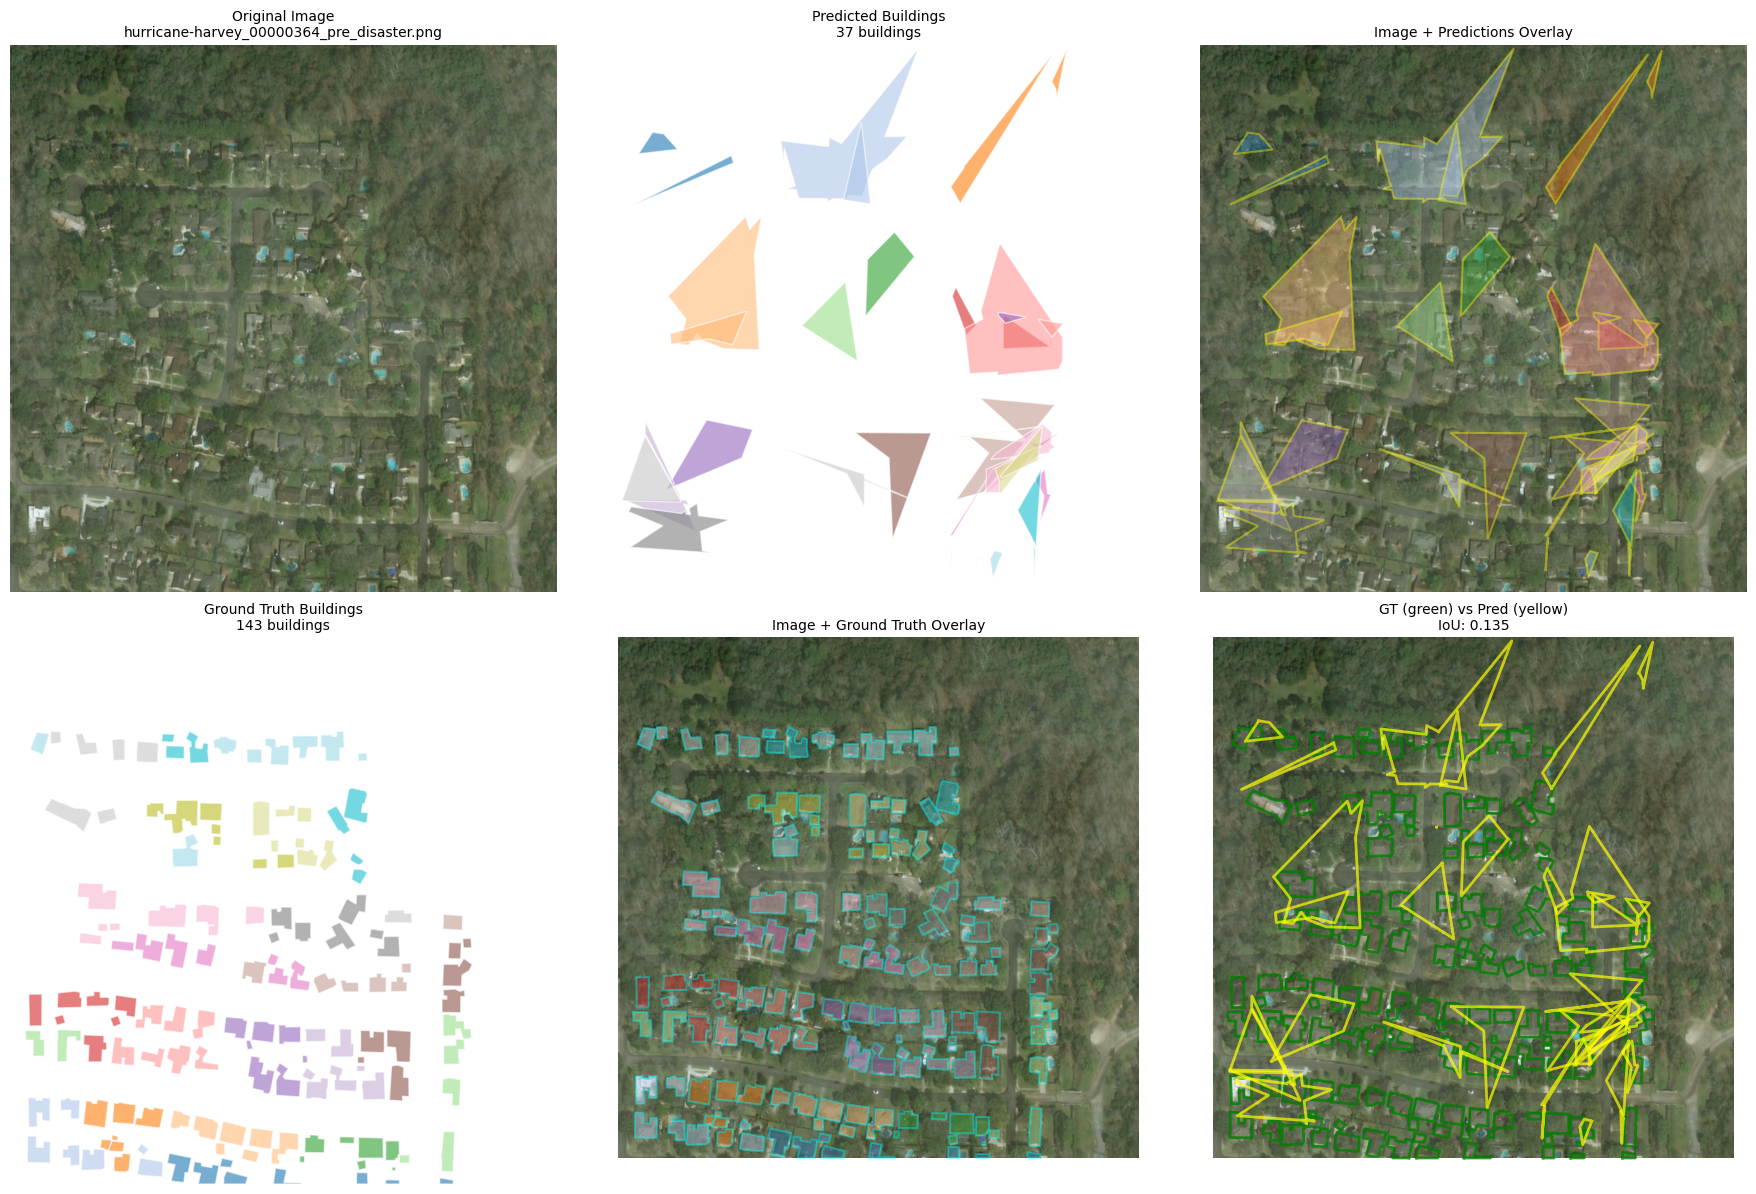


Image: hurricane-harvey_00000364_pre_disaster.png
Ground Truth Buildings: 143
Predicted Buildings: 37
Difference: -106
Image size: 1024 x 1024

📊 IoU Metrics:
  Overall IoU (pixel-based): 0.1347 (13.47%)
  Mean Per-Polygon IoU: 0.0337 (3.37%)
  Min IoU: 0.0000
  Max IoU: 0.4405
  Polygons with IoU > 0.5: 0/143



In [19]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from shapely import wkt as shapely_wkt
from shapely.geometry import Polygon
import random

def polygon_from_segmentation(segmentation):
    """Convert segmentation list to shapely polygon"""
    if not segmentation or len(segmentation[0]) < 6:
        return None
    coords = segmentation[0]
    points = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
    return Polygon(points)

def calculate_polygon_iou(gt_features, pred_list, img_width, img_height):
    """
    Calculate IoU between ground truth and predicted polygons
    
    Args:
        gt_features: Ground truth polygon features (from label JSON with 'wkt' format)
        pred_list: List of prediction dictionaries (from PolyWorld output with 'segmentation' format)
        img_width: Image width
        img_height: Image height
    
    Returns:
        overall_iou: Overall pixel-based IoU
        mean_per_polygon_iou: Mean per-polygon IoU
        per_polygon_ious: List of IoU scores for matched polygons
    """
    # Create binary masks for ground truth and predictions
    from PIL import ImageDraw
    gt_img = Image.new('L', (img_width, img_height), 0)
    draw_gt = ImageDraw.Draw(gt_img)
    
    for feature in gt_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            coords_int = [(int(x), int(y)) for x, y in coords]
            draw_gt.polygon(coords_int, fill=1)
    
    gt_mask = np.array(gt_img)
    
    # Draw predicted polygons
    pred_img = Image.new('L', (img_width, img_height), 0)
    draw_pred = ImageDraw.Draw(pred_img)
    
    for pred in pred_list:
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            coords_int = [(int(x), int(y)) for x, y in coords]
            draw_pred.polygon(coords_int, fill=1)
    
    pred_mask = np.array(pred_img)
    
    # Calculate overall IoU
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    overall_iou = intersection / union if union > 0 else 0.0
    
    # Calculate per-polygon IoU using Shapely
    gt_polygons = []
    pred_polygons = []
    
    for feature in gt_features:
        try:
            poly = shapely_wkt.loads(feature['wkt'])
            if poly.is_valid:
                gt_polygons.append(poly)
        except:
            pass
    
    for pred in pred_list:
        try:
            poly = polygon_from_segmentation(pred['segmentation'])
            if poly and poly.is_valid:
                pred_polygons.append(poly)
        except:
            pass
    
    # Calculate best match IoU for each ground truth polygon
    per_polygon_ious = []
    for gt_poly in gt_polygons:
        best_iou = 0.0
        for pred_poly in pred_polygons:
            try:
                intersection_area = gt_poly.intersection(pred_poly).area
                union_area = gt_poly.union(pred_poly).area
                if union_area > 0:
                    current_iou = intersection_area / union_area
                    best_iou = max(best_iou, current_iou)
            except:
                pass
        per_polygon_ious.append(best_iou)
    
    mean_per_polygon_iou = np.mean(per_polygon_ious) if per_polygon_ious else 0.0
    
    return overall_iou, mean_per_polygon_iou, per_polygon_ious


def visualize_predictions_with_ground_truth(image_path, pred_json_path, gt_json_path):
    """
    Visualize PolyWorld predictions vs ground truth with 6 panels
    
    Args:
        image_path: Path to the pre-disaster image
        pred_json_path: Path to the PolyWorld prediction JSON file
        gt_json_path: Path to the ground truth JSON file
    """
    # Load image
    img = Image.open(image_path)
    img_array = np.array(img)
    
    # Load prediction JSON (PolyWorld format - list of predictions)
    with open(pred_json_path, 'r') as f:
        predictions = json.load(f)
    
    # Load ground truth JSON
    with open(gt_json_path, 'r') as f:
        ground_truth = json.load(f)
    gt_xy_features = ground_truth['features']['xy']
    
    # Calculate IoU
    overall_iou, mean_polygon_iou, per_polygon_ious = calculate_polygon_iou(
        gt_xy_features, predictions, img_array.shape[1], img_array.shape[0]
    )
    
    # Create figure with 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # ROW 1: PREDICTIONS
    # 1. Original image
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title(f"Original Image\n{Path(image_path).name}", fontsize=10)
    axes[0, 0].axis('off')
    
    # 2. Predicted polygons only
    axes[0, 1].set_xlim(0, img_array.shape[1])
    axes[0, 1].set_ylim(img_array.shape[0], 0)
    axes[0, 1].set_aspect('equal')
    axes[0, 1].set_facecolor('black')
    axes[0, 1].set_title(f"Predicted Buildings\n{len(predictions)} buildings", fontsize=10)
    axes[0, 1].axis('off')
    
    # Draw predicted polygons
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(predictions), 1)))
    for idx, pred in enumerate(predictions):
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[0, 1].fill(x_coords, y_coords, color=color, alpha=0.6, edgecolor='white', linewidth=1)
    
    # 3. Overlay - Image + Predictions
    axes[0, 2].imshow(img_array)
    axes[0, 2].set_title("Image + Predictions Overlay", fontsize=10)
    axes[0, 2].axis('off')
    
    for idx, pred in enumerate(predictions):
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[0, 2].fill(x_coords, y_coords, color=color, alpha=0.4, edgecolor='yellow', linewidth=1.5)
    
    # ROW 2: GROUND TRUTH & COMPARISON
    # 4. Ground truth polygons only
    axes[1, 0].set_xlim(0, img_array.shape[1])
    axes[1, 0].set_ylim(img_array.shape[0], 0)
    axes[1, 0].set_aspect('equal')
    axes[1, 0].set_facecolor('black')
    axes[1, 0].set_title(f"Ground Truth Buildings\n{len(gt_xy_features)} buildings", fontsize=10)
    axes[1, 0].axis('off')
    
    # Draw ground truth polygons
    gt_colors = plt.cm.tab20(np.linspace(0, 1, max(len(gt_xy_features), 1)))
    for idx, feature in enumerate(gt_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = gt_colors[idx % len(gt_colors)]
            axes[1, 0].fill(x_coords, y_coords, color=color, alpha=0.6, edgecolor='white', linewidth=1)
    
    # 5. Image + Ground Truth Overlay
    axes[1, 1].imshow(img_array)
    axes[1, 1].set_title("Image + Ground Truth Overlay", fontsize=10)
    axes[1, 1].axis('off')
    
    for idx, feature in enumerate(gt_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = gt_colors[idx % len(gt_colors)]
            axes[1, 1].fill(x_coords, y_coords, color=color, alpha=0.4, edgecolor='cyan', linewidth=1.5)
    
    # 6. Ground truth (green) vs Predictions (yellow)
    axes[1, 2].imshow(img_array)
    axes[1, 2].set_title(f"GT (green) vs Pred (yellow)\nIoU: {overall_iou:.3f}", fontsize=10)
    axes[1, 2].axis('off')
    
    # Draw ground truth in green
    for feature in gt_xy_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            axes[1, 2].plot(x_coords, y_coords, color='green', linewidth=2, alpha=0.8)
    
    # Draw predictions in yellow
    for pred in predictions:
        poly = polygon_from_segmentation(pred['segmentation'])
        if poly and hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            axes[1, 2].plot(x_coords, y_coords, color='yellow', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics with IoU
    print(f"\n{'='*70}")
    print(f"Image: {Path(image_path).name}")
    print(f"Ground Truth Buildings: {len(gt_xy_features)}")
    print(f"Predicted Buildings: {len(predictions)}")
    print(f"Difference: {len(predictions) - len(gt_xy_features):+d}")
    print(f"Image size: {img_array.shape[1]} x {img_array.shape[0]}")
    print(f"\n📊 IoU Metrics:")
    print(f"  Overall IoU (pixel-based): {overall_iou:.4f} ({overall_iou*100:.2f}%)")
    print(f"  Mean Per-Polygon IoU: {mean_polygon_iou:.4f} ({mean_polygon_iou*100:.2f}%)")
    if per_polygon_ious:
        print(f"  Min IoU: {min(per_polygon_ious):.4f}")
        print(f"  Max IoU: {max(per_polygon_ious):.4f}")
        print(f"  Polygons with IoU > 0.5: {sum(1 for x in per_polygon_ious if x > 0.5)}/{len(per_polygon_ious)}")
    print(f"{'='*70}\n")


# Paths for PolyWorld predictions
pred_labels_dir = Path("/media/data/building_instance_tamu/PolyWorld/test_finetuned_scaled")
gt_labels_dir = Path("/media/data/building_instance_tamu/test/labels")
images_dir = Path("/media/data/building_instance_tamu/test/images")

# Get all prediction JSON files
pred_json_files = list(pred_labels_dir.glob("*.json"))
print(f"Found {len(pred_json_files)} PolyWorld prediction files\n")

if len(pred_json_files) > 0:
    # Randomly select one file to visualize
    random_index = random.randint(0, len(pred_json_files)-1)
    pred_json_path = pred_json_files[random_index]
    
    print(f"Randomly selected: {pred_json_path.name}\n")
    
    # Find corresponding files
    base_name = pred_json_path.stem
    img_path = images_dir / f"{base_name}.png"
    gt_json_path = gt_labels_dir / f"{base_name}.json"
    
    # Check if all files exist
    if all([img_path.exists(), gt_json_path.exists()]):
        print(f"✅ Found all files for: {base_name}")
        print(f"  - Image: {img_path.name}")
        print(f"  - Ground Truth: {gt_json_path.name}")
        print(f"  - Prediction: {pred_json_path.name}\n")
        
        visualize_predictions_with_ground_truth(img_path, pred_json_path, gt_json_path)
    else:
        print("❌ Missing files:")
        if not img_path.exists():
            print(f"  - Image: {img_path}")
        if not gt_json_path.exists():
            print(f"  - Ground Truth: {gt_json_path}")
else:
    print("❌ No prediction files found. Please run Part 1 first to generate predictions.")

In [2]:
import os
from pathlib import Path

# import your existing pipeline
from predict_tiled_polyworld import polyworld_inference_and_clean


# ============================================================
# BATCH RUNNER
# ============================================================

def run_batch(
    input_dir,
    output_dir,
    weights_dir,
    iou_thresh=0.20,
    small_thresh=50
):

    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    weights_dir = Path(weights_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    # collect only *pre_disaster.png images
    images = sorted(input_dir.glob("*_pre_disaster.png"))
    print(f"[INFO] Found {len(images)} images to process.")

    for img_path in images:
        base = img_path.stem  # e.g. guatemala-volcano_00000003_pre_disaster
        out_json = output_dir / f"{base}.json"

        print(f"\n[INFO] Processing {img_path.name}")
        polyworld_inference_and_clean(
            image_path=str(img_path),
            weights_dir=str(weights_dir),
            output_json=str(out_json),
            iou_thresh=iou_thresh,
            small_thresh=small_thresh,
        )
        print(f"[INFO] Finished {img_path.name}")
    
    print("\n[INFO] Batch processing complete!")


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    run_batch(
        input_dir="/media/data/building_instance_tamu/test/images/",
        output_dir="/media/data/building_instance_tamu/PolyWorld/test_finetuned_scaled/",
        weights_dir="/media/data/building_instance_tamu/PolyWorld/finetuned_v2",
        iou_thresh=0.20,
        small_thresh=50,
    )


[INFO] Found 933 images to process.

[INFO] Processing guatemala-volcano_00000003_pre_disaster.png
[INFO] Image size: 1024 × 1024
[INFO] Tile X positions: [0, 320, 640, 960]
[INFO] Tile Y positions: [0, 320, 640, 960]
[INFO] Raw polygons detected: 28
[INFO] After IoU merging: 28 polygons
[INFO] After small-fragment cleaning: 28 polygons
[INFO] Saved cleaned polygons → /media/data/building_instance_tamu/PolyWorld/test_finetuned_scaled/guatemala-volcano_00000003_pre_disaster.json
[INFO] Finished guatemala-volcano_00000003_pre_disaster.png

[INFO] Processing guatemala-volcano_00000005_pre_disaster.png
[INFO] Image size: 1024 × 1024
[INFO] Tile X positions: [0, 320, 640, 960]
[INFO] Tile Y positions: [0, 320, 640, 960]
[INFO] Raw polygons detected: 22
[INFO] After IoU merging: 20 polygons
[INFO] After small-fragment cleaning: 19 polygons
[INFO] Saved cleaned polygons → /media/data/building_instance_tamu/PolyWorld/test_finetuned_scaled/guatemala-volcano_00000005_pre_disaster.json
[INFO] Fin